# Code Example on PPMS_Toolkit

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from ppms_toolkit.sample import Sample
from ppms_toolkit.measurement import HeatCapacityMeasurement

from ppms_toolkit.measurement import debye_model_extended, debye_model

## Heat Capacity on Mn-PEA

In [2]:
# Initialize a sample
MnPEA = Sample(id=1,
            name = "Mn-PEA",
            mass = 7.8, 
            make_time="2025-1-12")

In [3]:
# Load a measurement data and assign it to sample 1
Mn_PEA_HC = HeatCapacityMeasurement(filepath='test_data/HC_test_data.Dat',
                                    sample=MnPEA, 
                                    field_strength=1000)

In [4]:
# Access to the list of Measurements
MnPEA.measurements

[HC exp, Mn-PEA with 1000 Oe ]

In [5]:
# Access to the processed pd.DataFrame of certain measurements
Mn_PEA_HC.dataframe

,Time Stamp (Seconds),Field (Oersted),Sample Temp (Kelvin),Samp HC (µJ/K),Samp HC Err (µJ/K),Samp HC/Temp (µJ/K/K)
0,3.953442e+09,999.633427,1.994420,0.909666,0.002630,0.456104
1,3.953442e+09,999.669310,2.199579,1.173588,0.002645,0.533551
2,3.953442e+09,999.645383,2.425263,1.529208,0.003681,0.630533
3,3.953442e+09,999.513853,2.673384,2.009654,0.004339,0.751726
4,3.953442e+09,999.573647,2.945506,2.601245,0.005344,0.883123
...,...,...,...,...,...,...
155,3.953278e+09,1000.034100,258.597710,7473.481000,20.690000,28.900028
156,3.953268e+09,999.998230,279.693800,8046.697200,18.560000,28.769666
157,3.953276e+09,999.908570,279.716630,8022.202300,16.790000,28.679747
158,3.953268e+09,1000.052000,279.733640,8012.184900,25.760000,28.642193


In [6]:
# Save a certain sample with all its measurements and metadata to a pickle file.
MnPEA.save()

In [7]:
# Load a Pickel file, later.
# MnPEA = Sample.load('Mn-PEA.pkl')

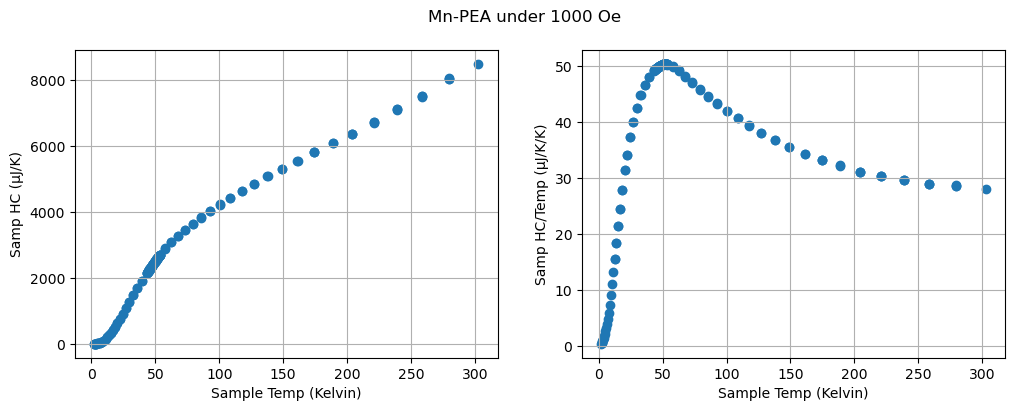

In [8]:
# plot the HC Data.
# The plot function returns the fig and ax object,
# so it's easy to manipulate and modify.
fig ,ax = Mn_PEA_HC.plot();

/Users/ryunosuke/Documents/Research/PPMS/PPMS_ToolKit/src/ppms_toolkit/measurement/utils.py:43: RuntimeWarning: overflow encountered in scalar power
  return np.where(denom == 0, 0, x**4 * ex / denom**2)


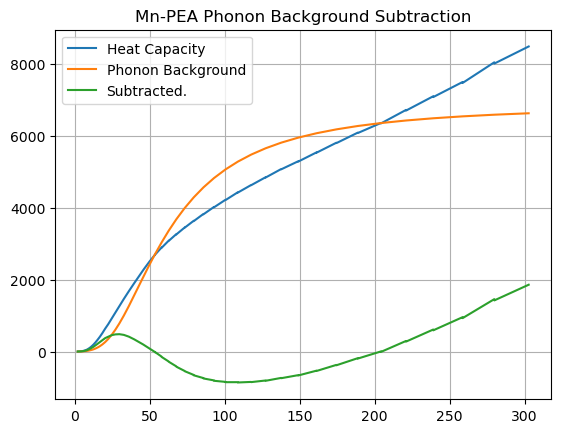

In [9]:
# Fit with default Debye Model, no bounding, no range.
T, subtracted_HC, fig, ax, params = Mn_PEA_HC.background_subtraction();

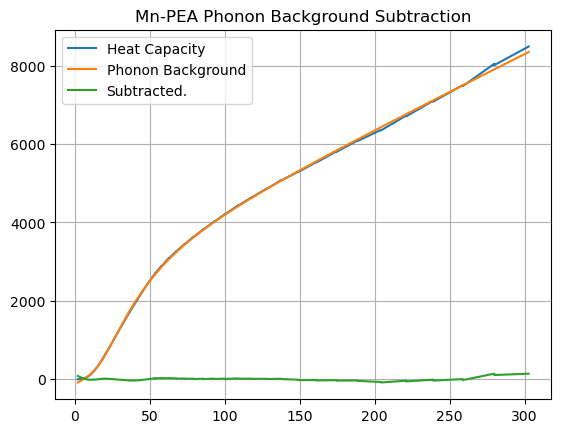

In [10]:
# Surely, you can fit with you own model function, with certain range and bounds to the fitting parameters.
fig, ax, *_  = Mn_PEA_HC.background_subtraction(model=debye_model_extended,
                                                                     mask_func=lambda T: (T>5) & (T<300),
                                                                     bounds=([1, 0.0001,-np.inf,-np.inf], 
                                                                             [500, 100,np.inf,np.inf]))

## VSM on 4Cl-Mn-BA

In [11]:
from ppms_toolkit.measurement import VSMMeasurement

In [12]:
Cl4MnBA = Sample(name='4Cl-Mn-BA', mass=1.88, make_time='2025-05-02')

In [13]:
m1 = VSMMeasurement(filepath='test_data/VSM_TestData_4CL/0P1T_FC.DAT',sample_orientation='In Plane', mode='MT',sample = Cl4MnBA)
m1

MT exp on 4Cl-Mn-BA with In Plane orientation at 1000Oe

In [14]:
m2 = VSMMeasurement(filepath='test_data/VSM_TestData_4CL/2P5K.DAT', sample_orientation='In Plane', mode='MH', sample=Cl4MnBA)
m2

MH exp on 4Cl-Mn-BA with In Plane orientation at 2.5K

In [15]:
import re
if re.search(pattern=r'FC', string=m1.filepath):
    print(1)

1


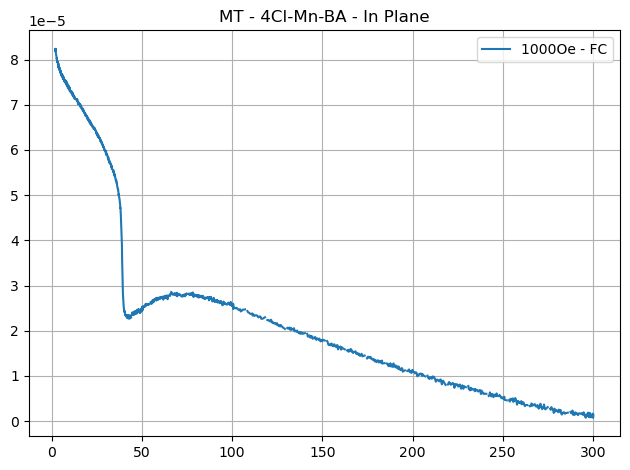

In [16]:
m1.plot()

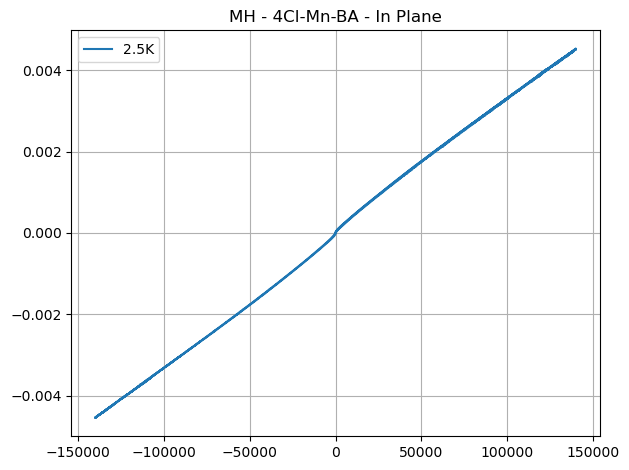

In [18]:
m2.plot()